## Imports

In [1]:
import pandas as pd
import seaborn as sns
import json

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl

## Load scores and plotting metadata

In [2]:
df = pd.read_csv("/home/jovyan/pert-bench-fusion-paper/results/scores/tahoe_deg.csv", index_col=0)

In [3]:
with open("/home/jovyan/pert-bench-fusion-paper/results/metadata/fig_index.json", "r") as f:
    fig_index = json.load(f)

method_map = fig_index["tahoe_deg"]
model_type_palette = fig_index['drugs_model_type_palette']
hue_order = fig_index['drugs_hue_order']
mpl.rcParams.update(fig_index["mpl_params"])
mpl.rcParams.update({"legend.loc": "upper right"})

## Aggregated figure

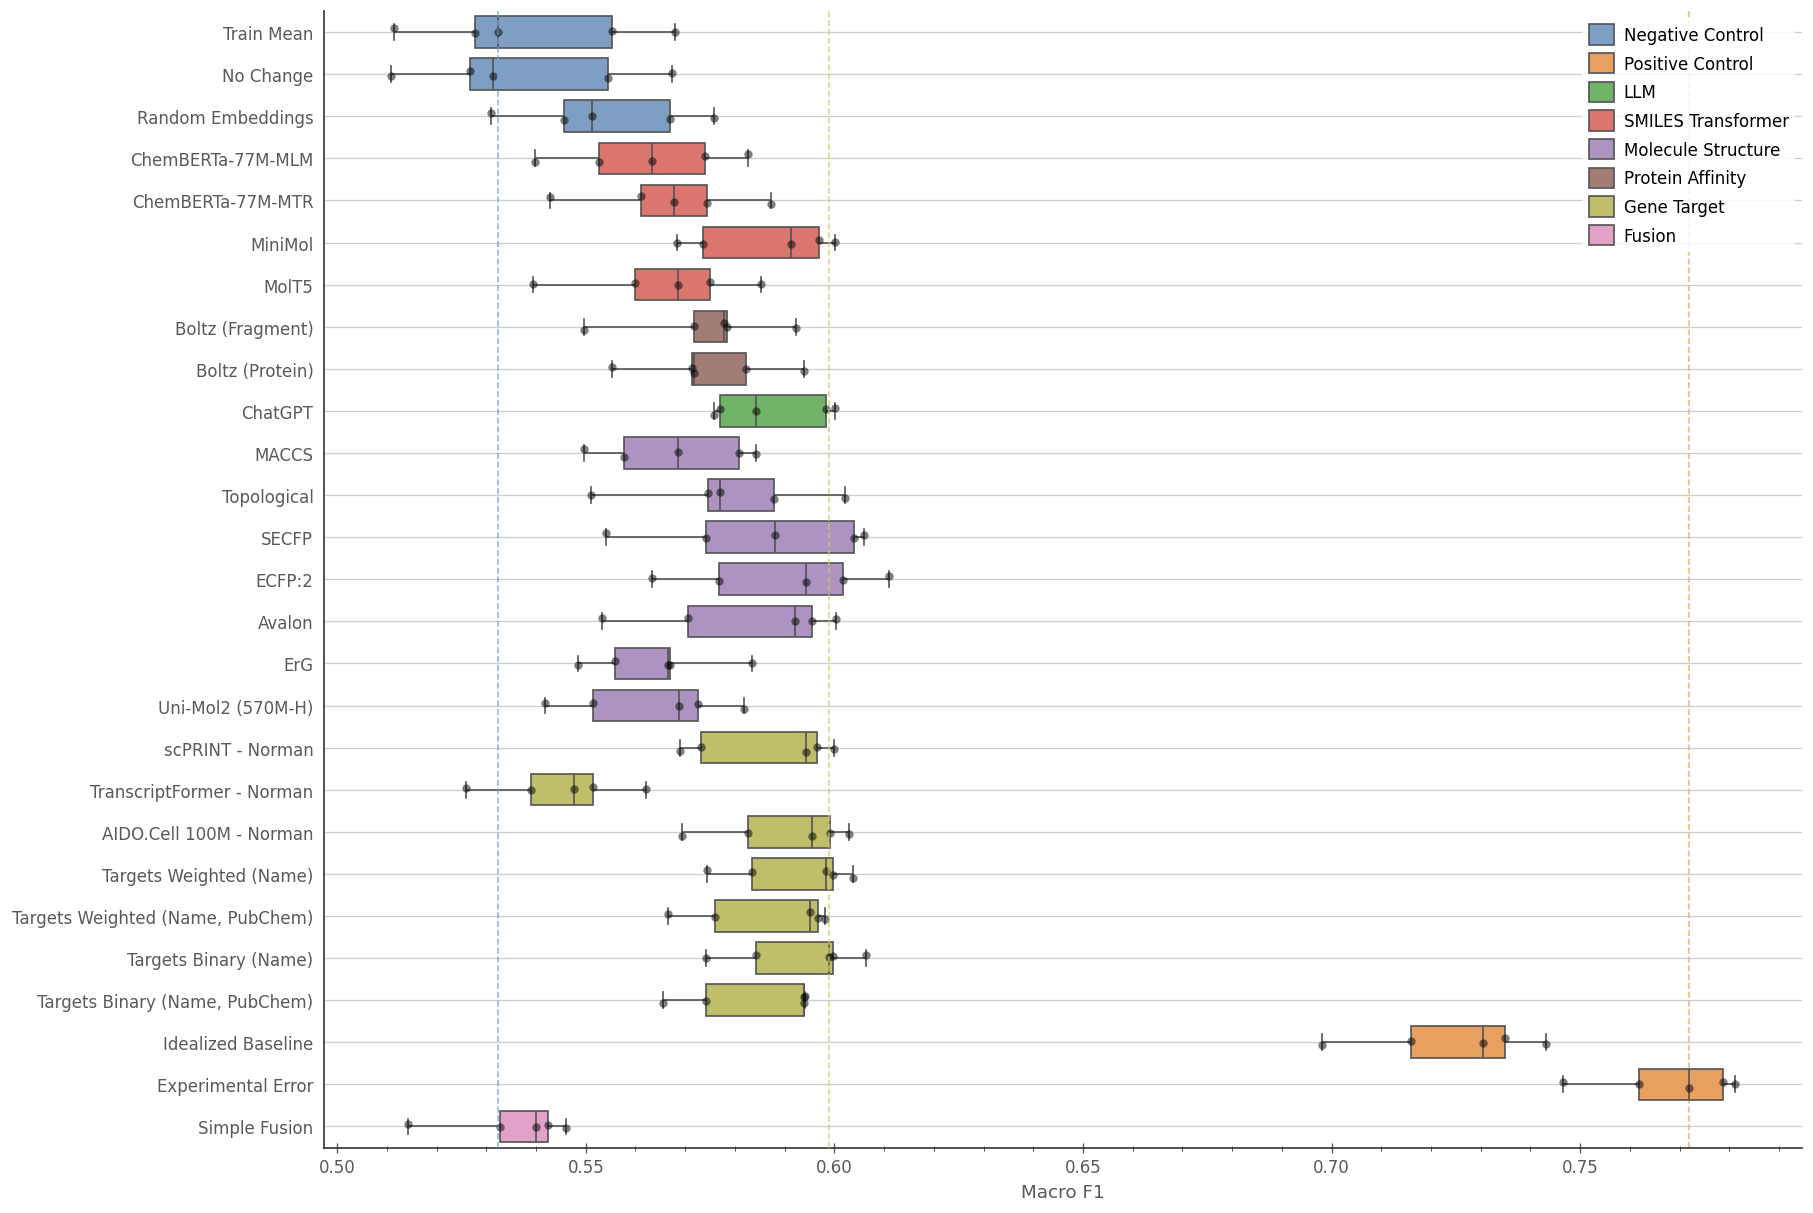

In [5]:
score = "f1_score"

fig, ax = plt.subplots(figsize=(15, 10), constrained_layout=True)

df_subset = df[df["name"].isin(method_map)].copy()
df_subset["fold"] = df_subset["fold"].apply(lambda x: x if "." not in str(x) else x.split(".")[1])
df_subset["Model type"] = df_subset["name"].apply(lambda x: method_map[x][1])
df_subset["name"] = df_subset["name"].apply(lambda x: method_map[x][0])

# Aggregate
df_subset = df_subset.groupby(["fold", "name", "Model type"])["f1_score"].mean().reset_index()

present_hues = [
    h for h in hue_order
    if h in df_subset["Model type"].unique()
]

# Boxplot
g = sns.boxplot(
    data=df_subset,
    y="name",
    order=[name for name, _ in method_map.values()],
    hue="Model type",
    hue_order=present_hues,
    x="f1_score",
    ax=ax,
    whis=(0, 100),
    width=0.75,
    palette=model_type_palette,
)

# Overlay stripplot
sns.stripplot(
    data=df_subset,
    y="name",
    order=[name for name, _ in method_map.values()],
    color="black",
    alpha=0.5,
    s=5,
    x="f1_score",
    ax=ax,
)

# Decorate
g.grid(axis="y")
g.set(ylabel=None, title="")
g.set_xlabel('Macro F1')
g.legend(title=None)

# Get the best performing model
best_mask = (
    (df_subset["Model type"] != "Positive Control") &
    (df_subset["Model type"] != "Fusion")
)
best_group = (
    df_subset.loc[best_mask]
    .groupby("name")["f1_score"]
    .median()
)
best_name = best_group.idxmax()
best_level = best_group.loc[best_name]
best_model_type = (
    df_subset.loc[df_subset["name"] == best_name, "Model type"]
    .iloc[0]
)

# Draw vertical lines
g.axvline(
    df_subset[df_subset["name"] == "Train Mean"]["f1_score"].median(),
    color=model_type_palette["Negative Control"],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)
g.axvline(
    df_subset[
        df_subset["name"] == f"Experimental Error"
    ]["f1_score"].median(),
    color=model_type_palette["Positive Control"],
    linestyle="--",
    linewidth=1,
    zorder=-99,
    alpha=0.75,
)
g.axvline(
    best_level,
    color=model_type_palette[best_model_type],
    linestyle="--",
    linewidth=1,
    zorder=99,
    alpha=0.75,
)
plt.savefig("fig_A7.pdf")